In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
import pandas as pd
from statsmodels.tsa.stattools import adfuller

In [2]:
# loading in cleaned data
produce_frame = pd.read_csv("cleaned_produce.csv")

# list of produce
produce_names = produce_frame["productname"].unique()


In [ ]:
def make_covar_stationary(data):
    d_best = 0

    # increase difference untill covaraince stationary
    while True:

        # adfuller method uses hypothesis test to see if data is covaraince stationary
        p_value = adfuller(data)[1]

        if p_value < 0.05:
            # it is likely covariance stationary
            return d_best, data
        
        else:
            # not covaraince stationary do increase d by 1
            d_best += 1
            data = np.diff(data, n=d_best)

# making all the data covariance stationary
produce_data_list = []
for produce in produce_names:

    # extract data for one produce
    data = produce_frame[produce_frame["productname"] == produce]["averageretail"].values
    norm_data = (data - data.mean()) / data.std()

    # makes data covaraince stationary
    d, covar_stat_norm_data = make_covar_stationary(norm_data)

    produce_data_list.append((covar_stat_norm_data, d))
        

Grid search for best p and q paramters. Assumes d is already found to prevent the grid searching finding a d that gets rid of data's structure

In [ ]:
def sm_arma(data, p_max=3, q_max=3, d=0, n=30):
    """
    Build an ARMA model with statsmodel and
    predict future n values.

    Parameters:
        data: data prepped to be fed into ARMA model
        p_max (int): maximum order of autoregressive model
        q_max (int): maximum order of moving average model
        n (int): number of values to predict

    Return:
        aic (float): aic of optimal model
        best_p
        best_q
    """
    
    # initializing paramters to optimize
    lowestAIC = np.inf
    best_p = p_max
    best_q = q_max

    # grid search p and q
    for p in range(1, p_max + 1):
        for q in range(1, q_max + 1):
                
            model = ARIMA(data, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False)
            results = model.fit()

            aic = results.aic
            
            
            # tracking best aic and parameters
            if aic < lowestAIC:
                lowestAIC = aic
                best_p = p
                best_q = q
        
    return lowestAIC, best_p, d, best_q

    # access phis and theta by model . arparams and maparams

In [ ]:
# initializing dictionar to turn into data frame which will be saved as a csv
produce_dict = {"Name" : [],
               "AIC" : [],
               "Best p": [],
               "Best d": [],
               "Best q": [],
               'phis': [],
               'thetas': []
               }

# fitting ARIMA model for each produce item
for produce_tuple, name in zip(produce_data_list, produce_names):

    produce_data = produce_tuple[0]
    d = produce_tuple[1]
    
    # grid search
    aic, p, d, q, phis, thetas = sm_arma(produce_data, p_max=5, q_max=5, d=d)

    # populate dictionary
    produce_dict["Name"].append(name)
    produce_dict["AIC"].append(aic)
    produce_dict["Best p"].append(p)
    produce_dict["Best d"].append(d)
    produce_dict["Best q"].append(q)
    print(f"{name}, aic:{aic}, p: {p}, d: {d}, q: {q}")

# saving to dataframe and saving as a file
opt_params_df = pd.DataFrame(produce_dict)
opt_params_df.to_csv('arima_optimal_params.csv') 


Grid searching for best p and q values in ARIMA model

In [6]:
print(sm_arma(train_asparagus, 2, 2, 1))

# returned  (1, 5, 1)

NameError: name 'train_asparagus' is not defined

1019


/home/jn552/Volume3_Project/fruit_venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/jn552/Volume3_Project/fruit_venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/jn552/Volume3_Project/fruit_venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/jn552/Volume3_Project/fruit_venv/lib/python3.10/site-packages/stats

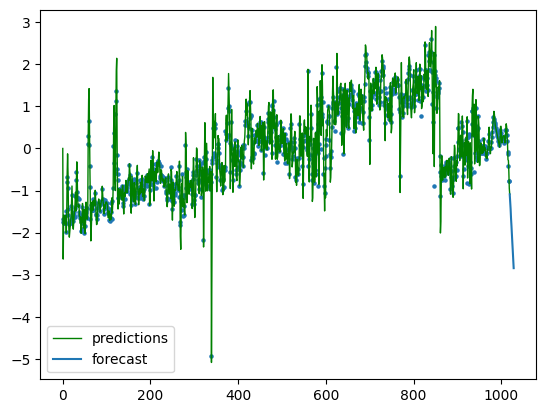

In [ ]:
model = ARIMA(train_asparagus, order=(2, 2, 0))
results = model.fit()
forecast = results.forecast(steps=10)
print(len(np.arange(len(norm_asparagus_price))))
plt.scatter(np.arange(len(norm_asparagus_price)), norm_asparagus_price, s=5)

predicts = results.predict(start=0,end=len(train_asparagus))
plt.plot(predicts, label="predictions", color="green", lw=1)
plt.plot(np.arange(len(train_asparagus), len(train_asparagus) + 10), forecast, label="forecast")
plt.plot()
plt.legend()
plt.show()

In [16]:
from scipy.stats.distributions import norm
from scipy.optimize import minimize

In [17]:
def kalman(F, Q, H, time_series):
    # Get dimensions
    dim_states = F.shape[0]

    # Initialize variables
    # covs[i] = P_{i | i-1}
    covs = np.zeros((len(time_series), dim_states, dim_states))
    mus = np.zeros((len(time_series), dim_states))

    # Solve of for first mu and cov
    covs[0] = np.linalg.solve(np.eye(dim_states**2) - np.kron(F, F), 
            np.eye(dim_states**2) @ Q.flatten()).reshape((dim_states, dim_states))
    mus[0] = np.zeros((dim_states,))

    # Update Kalman Filter
    for i in range(1, len(time_series)):
        # Assume u, R = 0
        SkInv = np.linalg.solve(H @ covs[i-1] @ H.T, np.eye(H.shape[0]))
        Kk_H_Pkk = covs[i-1] @ (H.T @ (SkInv @ (H @ covs[i-1])))
        covs[i] = F @ ((covs[i-1] - Kk_H_Pkk) @ F.T) + Q
        mus[i] = F @ mus[i-1] + (F @ (covs[i-1] @ (H.T @ SkInv))) @ (time_series[i-1] - H @ mus[i-1])
        
    return mus, covs

def state_space_rep(phis, thetas, mu, sigma):
    # Initialize variables
    dim_states = max(len(phis), len(thetas)+1)
    dim_time_series = 1 # hardcoded for 1d time_series

    F = np.zeros((dim_states, dim_states))
    Q = np.zeros((dim_states, dim_states))
    H = np.zeros((dim_time_series, dim_states))

    # Create F
    F[0, :len(phis)] = phis
    F[1:, :-1] = np.eye(dim_states - 1)
    # Create Q
    Q[0][0] = sigma**2
    # Create H
    H[0][0] = 1.
    H[0][1:len(thetas)+1] = thetas

    return F, Q, H, dim_states, dim_time_series

In [18]:
def arma_likelihood(stock_data, phis, thetas, mu=0, std=1):
    """
    Transfer the ARMA model into state space.
    Return the log-likelihood of the ARMA model.

    Parameters:
        file (str): data file
        phis (ndarray): coefficients of autoregressive model
        thetas (ndarray): coefficients of moving average model
        mu (float): mean of errorm
        std (float): standard deviation of error

    Return:
        log_likelihood (float)
    """
    z = stock_data
    F, Q, H, _, _ = state_space_rep(phis, thetas, mu, std)
    x_hats, Ps = kalman(F, Q, H, z)    # center data for Kalman filter
    
    log_likelihood = np.sum([
        np.log(norm.pdf(z[i], loc=H @ x_hats[i] + mu, scale=np.sqrt(H @ Ps[i] @ H.T))) for i in range(z.shape[0])
        ])  # get sum of logs using list comprehension
    
    return log_likelihood


def model_identification(stock_data, p, q, d):
    """
    Identify parameters to minimize AIC of ARMA(p,q) model

    Parameters:
        file (str): data file
        p_max (int): maximum order of autoregressive model
        q_max (int): maximum order of moving average model

    Returns:
        log likelihood of data given our parameters
    """
    time_series = np.diff(stock_data, n=d)  # do d differences using our found parameter
    n = len(time_series)
    
    def f(x): # x contains the phis, thetas, mu, and std
        try:
            ll = arma_likelihood(time_series, phis=x[:p], thetas=x[p:p+q], mu=x[-2], std=x[-1])
            if not np.isfinite(ll):
                return 1e10  # Bad
            return -ll
        except Exception:
            return 1e10

    k = p + q + 2
    x0 = np.zeros(k)
    x0[-2] = time_series.mean()
    x0[-1] = time_series.std()

    # get solution which maximizes the log likelihood
    sol = minimize(f,  x0, method="SLSQP")
    log_likelihood = -sol.fun   # save that log likelihood 

    return log_likelihood

In [19]:
# load in stock data
stock_data = np.array(pd.read_csv('cleaned_sp.csv')['Open'])
stock_data  = (stock_data - np.mean(stock_data)) / np.std(stock_data)

opt_params_df = pd.read_csv('arima_optimal_params.csv') # gives parameters for each fruit

max_likelihood = -np.inf    # to be updated to find best fruit

for index, row in opt_params_df.iterrows():
    fruit_name = row['Name']
    p, d, q = row['Best p'], row['Best d'], row['Best q']   # extract params

    # get log likelihood of stock data given that fruit's model
    likelihood = model_identification(stock_data, p, q, d) 
    print(f'{fruit_name}: {likelihood}')

    if likelihood > max_likelihood:
        best_fruit = fruit_name
        max_likelihood = likelihood

print(best_fruit)   # fruit who's model maximizes the likelihood of the data 

/var/folders/1x/yyjww82945d4813llglrgk9r0000gn/T/ipykernel_46294/2505200439.py:21: RuntimeWarning: invalid value encountered in sqrt
  np.log(norm.pdf(z[i], loc=H @ x_hats[i] + mu, scale=np.sqrt(H @ Ps[i] @ H.T))) for i in range(z.shape[0])


Asparagus: -10000000000.0
Avocados: 1226.3413875504834


/var/folders/1x/yyjww82945d4813llglrgk9r0000gn/T/ipykernel_46294/2505200439.py:21: RuntimeWarning: divide by zero encountered in log
  np.log(norm.pdf(z[i], loc=H @ x_hats[i] + mu, scale=np.sqrt(H @ Ps[i] @ H.T))) for i in range(z.shape[0])


Broccoli Bunches: 1232.7740499852443
Broccoli Crowns: 1231.6423311778244
Cantaloupe: 1231.9641180079789
Carrots: 1237.4987455395885
Cauliflower: 1233.6346102111165
Celery: -10000000000.0
Flame Grapes: -10000000000.0
Green Leaf Lettuce: -10000000000.0
Honeydews: 1232.7740499852443
Iceberg Lettuce: 1232.3864900585995
Nectarines: -10000000000.0
Oranges: 1235.6650925397958
Peaches: -10000000000.0
Plums: 1164.3617434409584
Potatoes: 1236.2848746179084
Red Leaf Lettuce: 1231.859311058551
Romaine Lettuce: 1235.9751617928555
Strawberries: -10000000000.0
Thompson Grapes: 1230.0082484829857


/var/folders/1x/yyjww82945d4813llglrgk9r0000gn/T/ipykernel_46294/2169149617.py:19: RuntimeWarning: overflow encountered in matmul
  Kk_H_Pkk = covs[i-1] @ (H.T @ (SkInv @ (H @ covs[i-1])))
/var/folders/1x/yyjww82945d4813llglrgk9r0000gn/T/ipykernel_46294/2169149617.py:20: RuntimeWarning: invalid value encountered in matmul
  covs[i] = F @ ((covs[i-1] - Kk_H_Pkk) @ F.T) + Q
/var/folders/1x/yyjww82945d4813llglrgk9r0000gn/T/ipykernel_46294/2169149617.py:18: RuntimeWarning: invalid value encountered in matmul
  SkInv = np.linalg.solve(H @ covs[i-1] @ H.T, np.eye(H.shape[0]))
/var/folders/1x/yyjww82945d4813llglrgk9r0000gn/T/ipykernel_46294/2169149617.py:19: RuntimeWarning: invalid value encountered in matmul
  Kk_H_Pkk = covs[i-1] @ (H.T @ (SkInv @ (H @ covs[i-1])))
/var/folders/1x/yyjww82945d4813llglrgk9r0000gn/T/ipykernel_46294/2505200439.py:21: RuntimeWarning: invalid value encountered in matmul
  np.log(norm.pdf(z[i], loc=H @ x_hats[i] + mu, scale=np.sqrt(H @ Ps[i] @ H.T))) for i in rang

Tomatoes: -10000000000.0
Carrots


## Carrots (probably not)